# Imports
Use fastai conda environment for consistent versioning

In [24]:
import shutil
import re
import os
import sys
import pandas as pd

from pathlib import Path
from tqdm import tqdm
from matplotlib import pyplot as plt
import numpy as np
from numpy import random
from scipy import stats
import pickle

# import fastai.tabular.all as fasttab
from sklearn.model_selection import RepeatedKFold
from sklearn.ensemble import RandomForestClassifier,  GradientBoostingRegressor
from sklearn.metrics import roc_curve, auc
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.utils import resample
import sklearn.metrics as skm


sys.path.append('/mnt/scripts/biliseq_he_class2')
from helpers import anno as annoHelper
%load_ext autoreload
%autoreload 2


results = Path('/mnt/results/v8/')
models = results.joinpath('models')
use_model = 'densenet169_1fold_1rep_20542bal_224px_v4'
method = 'slide'
csv_path = models.joinpath(use_model).joinpath('csv')
logs = Path('/mnt/logs/v8/training').joinpath('%s_v1' % use_model)
sampleinfo = Path('/mnt/sampleinfo')
slide_df = pd.read_csv(sampleinfo.joinpath('rand_valid_100slides_97cases_v4.tsv'),sep='\t')
infer_path = Path('/mnt/results/v8/models/').joinpath(use_model).joinpath('infer_csv')
feat_path = results.joinpath('features').joinpath(use_model).joinpath('testset')
feat_path.mkdir(parents=True,exist_ok=True)
tile_df = pd.read_csv(feat_path.joinpath('infer_tile_df_1037966t_100slides.csv'))

#Tab models use previous version until 10fold inference completed
tab_path = Path('/mnt/results/v8/models/').joinpath('densenet169_1fold_1rep_10933bal_224px').joinpath('tab_models')
print('Finished')

ModuleNotFoundError: No module named 'seaborn'

In [12]:
def vector_to_pbins_index(dat,pbins):
    out = np.zeros(dat.shape)
    for i,pbin in enumerate(pbins):
        idx = (dat >= pbin[0]) & (dat < pbin[1])
        out[idx] = i
    return out

def calc_feats(slide_df,
               tile_df,
               put_pos_thresh=0.16,
               norm=True):
    more_feat = pd.DataFrame([])
    slides = slide_df.slide_num.values
    best_t = put_pos_thresh
    for slide in slides:
        use = tile_df.slide == slide
        tsub=tile_df.loc[use,:].reset_index(drop=True)
        dat = tsub.p_pos.values
        more_feat.loc[slide,'mean_ppos'] = np.mean(dat)
        more_feat.loc[slide,'std_ppos'] = np.std(dat)
        more_feat.loc[slide,'median_ppos'] = np.median(dat)
        more_feat.loc[slide,'var_ppos'] = np.var(dat)        
        more_feat.loc[slide,'mean_ppos_over_bestt'] = int(np.mean(dat) > best_t)
        
        put_pos = dat>best_t
        if any(put_pos):
            more_feat.loc[slide,'prop_ppos'] = np.sum(put_pos)/len(dat)
            more_feat.loc[slide,'put_pos_mean'] = np.mean(dat[put_pos])
            more_feat.loc[slide,'put_pos_psum'] = np.sum(dat[put_pos])
            more_feat.loc[slide,'put_pos_std'] = np.std(dat[put_pos])
            more_feat.loc[slide,'put_pos_max'] = np.max(dat[put_pos])
            more_feat.loc[slide,'put_pos_min'] = np.min(dat[put_pos])
            more_feat.loc[slide,'put_pos_var'] = np.var(dat[put_pos])
        else:
            more_feat.loc[slide,'prop_ppos'] = 0
            more_feat.loc[slide,'put_pos_mean'] = 0
            more_feat.loc[slide,'put_pos_psum'] = 0
            more_feat.loc[slide,'put_pos_std'] = 0
            more_feat.loc[slide,'put_pos_max'] = 0
            more_feat.loc[slide,'put_pos_min'] = 0
            more_feat.loc[slide,'put_pos_var'] = 0
        
        more_feat.loc[slide,'put_neg_max'] = np.max(dat[~put_pos])
        more_feat.loc[slide,'put_neg_psum'] = np.sum(dat[~put_pos])
        more_feat.loc[slide,'put_neg_mean'] = np.mean(dat[~put_pos])
        more_feat.loc[slide,'put_neg_min'] = np.min(dat[~put_pos])
        more_feat.loc[slide,'put_neg_std'] = np.std(dat[~put_pos])
        more_feat.loc[slide,'put_neg_var'] = np.var(dat[~put_pos])
        
    stat_feat = more_feat.values
    #0-1 scaling
    if norm:            
        stat_feat = (stat_feat - np.min(stat_feat,axis=0))
        stat_feat = (stat_feat / np.max(stat_feat,axis=0))

    return stat_feat

#  Run inference on test slides using fully trained models (ALL TILES)
see : /model_fitting/infer/fastai_cnn_cv_train_inference_v8.py


# Load test slide inferences 

In [4]:
ifn = [str(x) for x in infer_path.glob('*all_valid_pred.csv')]
folds = len(ifn)
valid = pd.DataFrame(slide_df.loc[:,['slide','group','class','accession_number']])
all_y_true = []
all_y_pred = []
tile_inf = {'slide':[], 'x':[], 'y':[], 'p_pos':[],'cls':[]}
    
for fold in range(0,folds):
    fn = infer_path.joinpath('%s_%d_all_valid_pred.csv' % (method,fold))
    if fn.exists():
        df = pd.read_csv(fn)        
        u_slide = df.slide.unique()
        if any(slide_df.slide.isin(u_slide)):
            for slide in u_slide:
                idx = slide_df.slide.values == slide
                slide_idx = df.slide.values == slide            
                tile_p = df.loc[slide_idx,'p_pos'].values            
                tile_cls= df.loc[slide_idx,'slide_class'].str.contains('malig').values

                xt=[]
                yt=[]
                st=[slide] * np.sum(slide_idx)
                for fn in df.loc[slide_idx,'cur_path'].values:
                    _,x,y,_ = annoHelper.parse_tile_fn(fn)
                    xt.append(x)
                    yt.append(y)

                tile_inf['x'].extend(xt)
                tile_inf['y'].extend(yt)
                tile_inf['slide'].extend(st)                
                tile_inf['p_pos'].extend(tile_p)
                tile_inf['cls'].extend(tile_cls)
    else:
        print('Missing',fn)
tile_df = pd.DataFrame(tile_inf)
tile_df = tile_df.dropna(how='any').reset_index(drop=True)
fn = feat_path.joinpath('infer_tile_df_%dt_%dslides.csv' % (tile_df.shape[0],
                                              len(tile_df.slide.unique()))
                       )
print(fn)
tile_df.to_csv(fn, index=False)
print(len(tile_df.slide.unique()),
      tile_df.shape[0])
tile_df.head()

/mnt/results/v8/features/densenet169_1fold_1rep_20542bal_224px_v4/testset/infer_tile_df_1037966t_100slides.csv
100 1037966


,slide,x,y,p_pos,cls
0,1013926,6832,74032,0.108576,False
1,1013926,2912,22736,0.001361,False
2,1013926,8400,109200,0.038086,False
3,1013926,4928,25088,0.005370,False
4,1013926,5712,8064,0.000243,False


In [60]:
print(len(tile_df.slide.unique()),
      tile_df.shape[0])

100 1037966


# Load test slide inference

In [3]:
tile_df = pd.read_csv('/mnt/results/v8/features/densenet169_1fold_1rep_20542bal_224px_v4/testset/infer_tile_df_1037966t_100slides.csv')

# Make validation summary

In [7]:
valid = pd.DataFrame(slide_df.loc[:,['slide','group','class','accession_number']])
for slide in tile_df.slide.unique():   
    slide_idx = tile_df.slide.values == slide
    idx = slide_df.slide.values == slide
    if np.any(slide_idx):
            tile_p = tile_df.loc[slide_idx,'p_pos'].values
            m_p = np.mean(tile_p)
            valid.loc[idx,'mean_p_pos'] = m_p
isnan = valid.mean_p_pos.isna().values #?
new_slide_df = slide_df.loc[~isnan,:]
valid = valid.dropna(how='any').reset_index(drop=True)
valid.head()

,slide,group,class,accession_number,mean_p_pos
0,1013926,benign,False,PHS20-10166 - 2 - 1013926,0.200505
1,400130,malignant,True,PHS20-31037 - 1 - 400130,0.242599
2,1014025,malignant,True,PHS19-7430 - 1014025,0.206825
3,1014063,benign,False,PHS19-8072 - 1014063,0.047857
4,1014031,benign,False,PHS19-1935 - 1014031,0.110751


In [62]:
# isnan = valid.mean_p_pos.isna().values #?
print(isnan.shape,slide_df.shape,new_slide_df.shape)
new_slide_df.index = new_slide_df.slide.values
print(np.sum(new_slide_df.index == valid.slide.values))


(100,) (100, 20) (100, 20)
100


# Validation set performance n = 100 slides

34 34


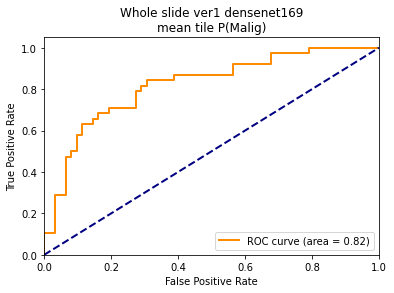

In [8]:
y_score = valid.mean_p_pos.values
y_true = valid.loc[:,'group'].str.contains('malig').astype(int).values
fpr, tpr, thr = skm.roc_curve(y_true,
                              y_score,
                              drop_intermediate=True)
print(len(fpr),len(tpr))
roc_auc = auc(fpr, tpr)

plt.figure()
lw = 2
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=lw,
    label="ROC curve (area = %0.2f)" % roc_auc,
)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Whole slide ver1 densenet169\nmean tile P(Malig)")
plt.legend(loc="lower right")
plt.show()


Thresh 0.155 
Accuracy 0.7576400679117148 
Specificity 0.7258064516129032 
Sensitivity 0.7894736842105263
Thresh 0.25 
Accuracy 0.7016129032258065 
Specificity 0.9032258064516129 
Sensitivity 0.5


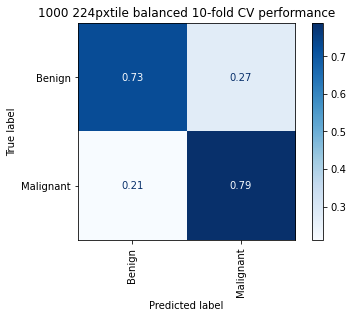

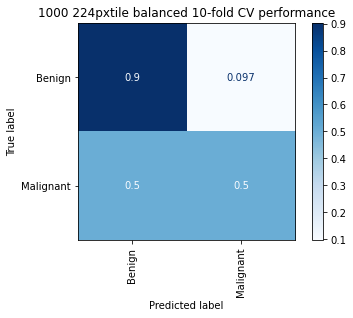

In [39]:
norm = True
#Values from notebook 04:
best_t = 0.155 #Calculated from 10fold CV on TRAINING SET (different cases and slides!)
best_spec = 0.25 #Calculated from 10fold CV on TRAINING SET (different cases and slides!)
threshes = [best_t, best_spec]
for use_t in threshes:
    y_true =  valid.loc[:,'class'].values
    y_pred = valid.mean_p_pos.values > use_t
    cm = skm.confusion_matrix(y_true, y_pred)
    if norm:
        cm =  cm/ (np.ones((2,2)) * np.sum(cm,axis=1)).T
    disp = skm.ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=['Benign','Malignant'])
    ax=disp.plot(cmap='Blues')
    plt.xticks(rotation=90)
    plt.title('1000 224pxtile balanced 10-fold CV performance')


    ac = (cm[0,0] + cm[1,1]) / np.sum(cm.reshape(-1,1))
    sp = cm[0,0] / np.sum(cm,axis=1)[0]
    sen = cm[1,1] /  np.sum(cm,axis=1)[1]
    print('Thresh',use_t,
          '\nAccuracy',ac, 
          '\nSpecificity',sp,
          '\nSensitivity',sen)

# Extract spatial features

In [65]:
pbins = [[2.3306949e-19, 1.6597538e-07],
        [1.6599532e-07, 8.5704363e-07],
        [8.570608e-07, 2.6130247e-06],
        [2.6130695e-06, 6.6449984e-06],
        [6.6451694e-06, 1.5280224e-05],
        [1.528037e-05, 3.3370972e-05],
        [3.3372024e-05, 7.120561e-05],
        [7.1206094e-05, 0.00015340053],
        [0.00015340783, 0.0003436641],
        [0.0003436928, 0.0008139474],
        [0.0008139482, 0.0021406421],
        [0.0021406626, 0.006389423],
        [0.006389768, 0.022844505],
        [0.022844516, 0.10245558],
        [0.10246198, 0.44730905],
        [0.44731876, 0.89797425],
        [0.89798445, 0.9929132],
        [0.99291354, 0.99966085],
        [0.99966085, 0.99998987],
        [0.99998987, 1.0]]
nq = len(pbins) #20
n = 11 #num tile neighbors
p = n //2
ts = 224
slides =  new_slide_df.slide_num.values
features = pd.DataFrame([])
version = 2
print(use_model)
for slide in tqdm(slides):
    # print('\n' + str(slide))
    use = tile_df.slide == slide
    tsub=tile_df.loc[use,:].reset_index(drop=True)
    dat = tsub.p_pos.values
    if version == 1:
        qidx = vector_to_quantile_index(dat, nq) #Do this instead with flat p-value bins from 0-1 ??
    elif version == 2:
        qidx = vector_to_pbins_index(dat,pbins)
    axi=1
    all_neighbors=[]
    for i in range(0,nq):
        # print('%d,' % (i), end = '') # Way to prevent newline
        idx = np.argwhere(qidx == i).flatten()
        x_tot=[]
        y_tot=[]
        w_tot=[]
        if any(idx):
            for ii,tid in enumerate(idx):        
                xx,yy = tsub.loc[tid,['x','y']]
                xn = tsub.x.values - xx
                yn = tsub.y.values - yy
                keep = (xn >= -(p*ts)) & (xn < (p+2)*ts) \
                        & (yn >= -(p*ts)) & (yn < (p+2)*ts)
                x_tot.extend(xn[keep])
                y_tot.extend(yn[keep])
                w_tot.extend(dat[keep])
            x_bin = np.array([x for x in range(((-p * ts)),(p+3)*ts,ts)])
            y_bin = x_bin        
            nn,_,_ = np.histogram2d(x = x_tot,
                                    y = y_tot,
                                    bins = [x_bin,y_bin],
                                    density = True,
                                    weights = w_tot)
        else:
            nn = np.zeros((n+1,n+1))
        all_neighbors.extend(nn.ravel())
    features.loc[:,slide] = all_neighbors
tt = features.transpose()
fn = feat_path.joinpath('%dpbins_%ddim_%dslides_nbnormed_density_v%d.csv' % (nq,
                                                                            (n+1),
                                                                             tt.shape[0],
                                                                             version))
print(fn)
print(tt.shape)
tt.to_csv(fn)   

densenet169_1fold_1rep_20542bal_224px_v4


100%|██████████| 100/100 [13:13<00:00,  7.93s/it]


/mnt/results/v8/features/densenet169_1fold_1rep_20542bal_224px_v4/testset/20pbins_12dim_100slides_nbnormed_density_v2.csv
(100, 2880)


/mnt/results/v8/features/densenet169_1fold_1rep_10933bal_224px/testset/20pbins_12dim_100slides_nbnormed_density_v2.csv

# Load and create final featureset:

In [13]:
npcs = 44
seed = 35
whiten = False
tt = pd.read_csv(feat_path.joinpath(
                '20pbins_12dim_100slides_nbnormed_density_v2.csv'),
                 index_col=0)
tile_df = pd.read_csv(feat_path.joinpath('infer_tile_df_1037966t_100slides.csv'))
all_space = tt.copy()

all_space = (all_space.T - np.min(tt, axis=1)).T
all_space = (all_space.T / np.max(all_space, axis=1)).T
all_space = all_space.dropna()
pca = PCA(n_components = npcs, 
          whiten=whiten,
          random_state=seed) # whiten=True)
X_r0 = pca.fit(all_space).transform(all_space)
use_norm = True
use_thresh = 0.25 #best spec for tiles see notebook 04
stat_feat =calc_feats(new_slide_df,
                      tile_df,
                      put_pos_thresh=use_thresh,
                      norm= use_norm) 
all_feat = np.concatenate((stat_feat,
                           X_r0),
                           axis=1) 
print(all_feat.shape)

(100, 62)


# Plot feature space using PCA

Text(0.5, 1.0, 'Kmeans = 2 of features')

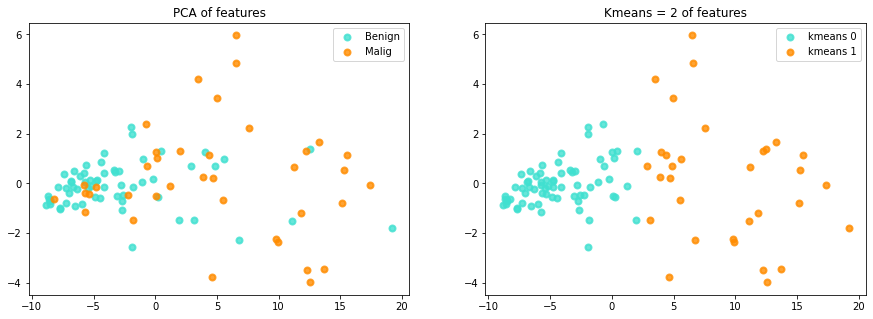

In [14]:
pca = PCA(n_components = 2)
X_r = pca.fit(all_feat).transform(all_feat)
y = new_slide_df.anno_class.str.contains('malig').values
target_names=['Benign','Malig']
fig = plt.figure(figsize=(15,5))
colors = ["turquoise", "darkorange"]
lw = 2

ax = fig.add_subplot(1,2,1)
for color, i, target_name in zip(colors, [0, 1], target_names):
    ax.scatter(
        X_r[y == i, 0], X_r[y == i, 1], color=color, alpha=0.8, lw=lw, label=target_name
    )
ax.legend(loc="best", shadow=False, scatterpoints=1)
ax.set_title("PCA of features")


kmeans = KMeans(n_clusters=2, random_state=0).fit(all_feat)
y = kmeans.labels_
ax = fig.add_subplot(1,2,2)
target_names=['kmeans 0', 'kmeans 1']
for color, i, target_name in zip(colors, [0,1], target_names):
    ax.scatter(
        X_r[y == i, 0], X_r[y == i, 1], color=color, alpha=0.8, lw=lw, label=target_name
    )
ax.legend(loc="best", shadow=False, scatterpoints=1)
ax.set_title("Kmeans = 2 of features")

# Perform tabular inference

In [15]:
use_rf = True
kfold = 10
rep = -1
fold_rep_tot = 100
gb_path = tab_path.joinpath('gb')
rf_path = tab_path.joinpath('rf')
print(gb_path,rf_path)
valid_preds = pd.DataFrame(np.zeros((new_slide_df.shape[0],fold_rep_tot))+np.nan)
valid_preds.index = new_slide_df.index #something like this, need equiv. of slide_df but with nan ind drop
for fold_rep in range(0,fold_rep_tot):
    fold = (fold_rep % kfold)
    if fold == 0:
        rep = rep+1
        
    fn='%02.0f_%02.0frep_%02.0ffold.pkl' % (fold_rep,rep,fold)
    gb_est = pickle.load(open(gb_path.joinpath(fn), 'rb'))
    X_val = all_feat
    y_val = new_slide_df.loc[:,'class'].values.astype(float)
    pred_gb = gb_est.predict(X_val)
    if use_rf:
        rf_est = pickle.load(open(rf_path.joinpath(fn), 'rb'))
        pred_rf = rf_est.predict_proba(X_val)[:,1]
        valid_preds.iloc[:,fold_rep]= (pred_gb*0.9 + pred_rf * 0.1)
    else:
        valid_preds.iloc[:,fold_rep]= pred_gb
    
print('Finished')

/mnt/results/v8/models/densenet169_1fold_1rep_10933bal_224px/tab_models/gb /mnt/results/v8/models/densenet169_1fold_1rep_10933bal_224px/tab_models/rf
Finished


In [73]:
print(new_slide_df.shape, valid_preds.shape)

(100, 20) (100, 100)



Accuracy 0.6914261460101867 
Specificity 0.9354838709677419 
Sensitivity 0.4473684210526316

Accuracy 0.7788624787775891 
Specificity 0.7419354838709677 
Sensitivity 0.8157894736842105


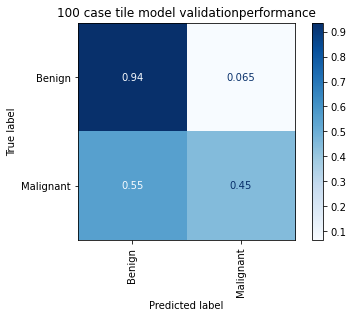

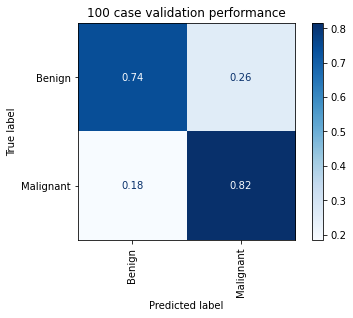

In [16]:
table_norm = True
nrep = 100
best_spec = 0.972 #72 #72 #Calculated with training set only! see notebook 07
best_t = 0.646 #Calculated with training set only! see notebook 07
use_reps = [x for x in range(0,nrep)]
y_pred = np.nanmean(valid_preds.iloc[:,use_reps].values,axis=1) > best_spec
y_true = new_slide_df.loc[:,'class'].values
cm = skm.confusion_matrix(y_true.astype(float), 
                          y_pred.astype(float))
if table_norm:
    cm =  cm/ (np.ones((2,2)) * np.sum(cm,axis=1)).T
disp = skm.ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Benign','Malignant'])
ax=disp.plot(cmap='Blues')
plt.xticks(rotation=90)
plt.title('100 case tile model validationperformance')


ac = (cm[0,0] + cm[1,1]) / np.sum(cm.reshape(-1,1))
sp = cm[0,0] / np.sum(cm,axis=1)[0]
sen = cm[1,1] /  np.sum(cm,axis=1)[1]
print('\nAccuracy',ac, 
      '\nSpecificity',sp,
      '\nSensitivity',sen)

y_pred = np.nanmean(valid_preds.iloc[:,use_reps].values,axis=1) > best_t
y_true = new_slide_df.loc[:,'class'].values
cm = skm.confusion_matrix(y_true.astype(float), 
                          y_pred.astype(float))
if table_norm:
    cm =  cm/ (np.ones((2,2)) * np.sum(cm,axis=1)).T
disp = skm.ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Benign','Malignant'])
ax=disp.plot(cmap='Blues')
plt.xticks(rotation=90)
plt.title('%d case validation performance' % new_slide_df.shape[0])


ac = (cm[0,0] + cm[1,1]) / np.sum(cm.reshape(-1,1))
sp = cm[0,0] / np.sum(cm,axis=1)[0]
sen = cm[1,1] /  np.sum(cm,axis=1)[1]
print('\nAccuracy',ac, 
      '\nSpecificity',sp,
      '\nSensitivity',sen)

31 31


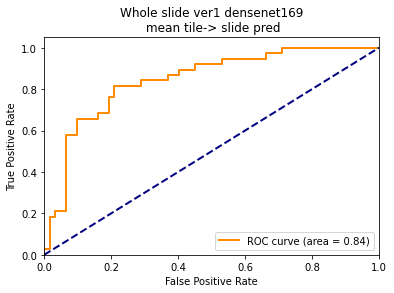

In [17]:
y_score = np.nanmean(valid_preds.iloc[:,use_reps].values,axis=1)
y_true = new_slide_df.loc[:,'class'].values
fpr, tpr, thr = skm.roc_curve(y_true,
                              y_score,
                              drop_intermediate=True)
print(len(fpr),len(tpr))
roc_auc = auc(fpr, tpr)

plt.figure()
lw = 2
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=lw,
    label="ROC curve (area = %0.2f)" % roc_auc,
)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Whole slide ver1 densenet169\n mean tile-> slide pred")
plt.legend(loc="lower right")
plt.show()


# Estimate pathology spec and sense using followup diagnosis as truth


Accuracy 0.8015873015873016 
Specificity 1.0 
Sensitivity 0.6031746031746031
3 3


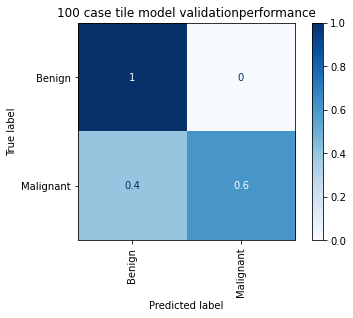

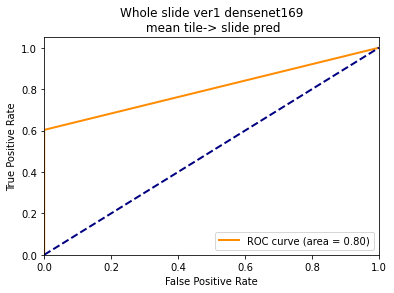

In [18]:
y_pred = new_slide_df.loc[:,'path_pos'].values
y_true = new_slide_df.loc[:,'fu_pos'].values
cm = skm.confusion_matrix(y_true.astype(float), 
                          y_pred.astype(float))
if table_norm:
    cm =  cm/ (np.ones((2,2)) * np.sum(cm,axis=1)).T
disp = skm.ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Benign','Malignant'])
ax=disp.plot(cmap='Blues')
plt.xticks(rotation=90)
plt.title('%d case tile model validationperformance' % new_slide_df.shape[0])


ac = (cm[0,0] + cm[1,1]) / np.sum(cm.reshape(-1,1))
sp = cm[0,0] / np.sum(cm,axis=1)[0]
sen = cm[1,1] /  np.sum(cm,axis=1)[1]
print('\nAccuracy',ac, 
      '\nSpecificity',sp,
      '\nSensitivity',sen)

fpr, tpr, thr = skm.roc_curve(y_true,
                              y_pred,
                              drop_intermediate=True)
print(len(fpr),len(tpr))
roc_auc = auc(fpr, tpr)

plt.figure()
lw = 2
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=lw,
    label="ROC curve (area = %0.2f)" % roc_auc,
)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Whole slide ver1 densenet169\n mean tile-> slide pred")
plt.legend(loc="lower right")
plt.show()

# Combine pathologist with model: if model says malig, overrule pathologist

In [53]:
best_spec = 0.972 #72 #72 #72 #Calculated with training set only! see notebook 07
best_t = 0.646 #Calculated with training set only! see notebook 07
# use_reps = [x for x in range(0,nrep)]
# y_pred = np.nanmean(valid_preds.iloc[:,use_reps].values,axis=1) > best_spec
        
y_pred_path = new_slide_df.loc[:,'path_pos'].values
y_pred_model = np.nanmean(valid_preds.iloc[:,use_reps].values,axis=1) > best_spec
y_true = new_slide_df.loc[:,'fu_pos'].values

model_diff = y_pred_model & ~y_pred_path
#Are those differences correct
diff_correct = y_true[model_diff]
print(np.sum(model_diff), diff_correct)


4 [False False False False]


In [33]:
valid_preds

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.927467,0.771640,0.927467,0.767464,0.926467,0.767640,0.930467,0.770640,0.764640,0.769640,...,0.770640,0.765640,0.923467,0.770640,0.766640,0.767640,0.766640,0.928467,0.929467,0.925467
1,0.930931,0.931931,0.983988,0.852418,0.980988,0.929931,0.981988,0.933931,0.938931,0.935931,...,0.931931,0.928931,0.853418,0.938931,0.983988,0.938931,0.987988,0.933931,0.935931,0.968849
2,0.983988,0.688779,0.847606,0.674645,0.853606,0.688779,0.847606,0.691779,0.690779,0.693779,...,0.697779,0.693779,0.849786,0.694779,0.688779,0.690779,0.687779,0.979988,0.849606,0.855786
3,0.004012,0.001012,0.002012,0.002012,0.004012,0.002012,0.005012,0.004012,0.002012,0.001012,...,0.003012,0.006012,0.003012,0.002012,0.002012,0.004012,0.002012,0.004012,0.006012,0.001012
4,0.340188,0.330188,0.326188,0.226052,0.335188,0.335188,0.338188,0.337188,0.334188,0.330188,...,0.333188,0.234956,0.335423,0.332188,0.339188,0.330188,0.336188,0.341188,0.330188,0.342423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.001012,0.000012,0.002012,0.003012,0.005012,0.001012,0.002012,0.004012,0.002012,0.001012,...,0.005012,0.003012,0.002012,0.002012,0.000012,0.000012,0.001012,0.003012,0.004012,0.002012
96,0.702768,0.571386,0.618258,0.402461,0.625258,0.574386,0.622258,0.576386,0.577386,0.428163,...,0.580386,0.305050,0.510257,0.578386,0.626258,0.566386,0.625258,0.696768,0.569386,0.631263
97,0.116622,0.119622,0.246993,0.006012,0.182899,0.115622,0.185899,0.120622,0.116622,0.119622,...,0.119622,0.117622,0.111622,0.115622,0.254993,0.119622,0.255993,0.118622,0.114622,0.228052
98,0.206488,0.081106,0.083106,0.080084,0.078106,0.079106,0.078106,0.084106,0.085106,0.080106,...,0.087106,0.083106,0.083084,0.081106,0.083106,0.082106,0.085106,0.206488,0.078106,0.143520


In [25]:
new_slide_df.head()

,Unnamed: 0,accession_number,pathologic_diagnosis,dob,location,follow_up_diagnosis,notes,phs,section_num,slide_num,fu_pos,path_pos,anno_fn,anno_class,raw_fn,anno_pnfn,tile_pn,class,slide,group
0,287,PHS20-10166 - 2 - 1013926,Negative for Adenocarcinoma,6/12/1947,Distal,Benign Stricture,NaN,PHS20-10166,2.0,1013926,False,False,NaN,benign,PHS20-10166 - 2 - 1013926.svs,NaN,NaN,False,1013926,benign
1,341,PHS20-31037 - 1 - 400130,Adenocarcinoma,4/15/1953,Hilar,Intrahepatic Cholangiocarcinoma,NaN,PHS20-31037,1.0,400130,True,True,NaN,malignant,PHS20-31037 - 1 - 400130.svs,NaN,NaN,True,400130,malignant
2,154,PHS19-7430 - 1014025,Adenocarcinoma,11/12/1968,Hilar,Intrahepatic Cholangiocarcinoma,PSC,PHS19-7430,NaN,1014025,True,True,NaN,malignant,PHS19-7430 - 1014025.svs,NaN,NaN,True,1014025,malignant
3,156,PHS19-8072 - 1014063,Negative for Adenocarcinoma,12/14/1948,Hilar,Benign Stricture,PSC,PHS19-8072,NaN,1014063,False,False,NaN,benign,PHS19-8072 - 1014063.svs,NaN,NaN,False,1014063,benign
4,145,PHS19-1935 - 1014031,Negative for Adenocarcinoma,10/16/1926,Mid,Extrahepatic Cholangiocarcinoma,NaN,PHS19-1935,NaN,1014031,True,False,NaN,benign,PHS19-1935 - 1014031.svs,NaN,NaN,False,1014031,benign


In [26]:
print(new_slide_df.shape)
out = new_slide_df.loc[:,
                       ['accession_number',
                        'location',
                        'pathologic_diagnosis',
                        'anno_class',
                        'follow_up_diagnosis',
                       ]]
temp = np.nanmean(valid_preds.iloc[:,use_reps].values,axis=1) > best_spec
new=np.zeros(temp.shape).astype(str)
new[temp] = 'malignant'
new[~temp] = 'benign'
out.loc[:,'model_call_best_spec'] =  new
out.loc[:,'model_call_prob_pos'] =   np.nanmean(valid_preds.iloc[:,use_reps].values,axis=1) 
out.to_csv(sampleinfo.joinpath('model_calls_020323.csv'))

(100, 20)
